# EEU4C16/EEP5C16 Lab 7 - Fast Single Image Super-Resolution

## Background
Super-resolution is a technique in image and video processing whereby a low resolution (LR) image/video frame is upsampled to a higher resolution (HR). This has numerous applications for:

- Balancing image/video quality and transmission efficiency for websites.

- Upscaling of photos taken on mobile devices ([Google Research Blog - Enhance! RAISR Sharp Images with Machine Learning](https://research.google/blog/enhance-raisr-sharp-images-with-machine-learning/)).

- Upscaling of video games ([NVIDIA - DLSS 4](https://www.nvidia.com/en-us/geforce/technologies/dlss/)).

Fast super-resolution is of utmost importance for real-time applications and a number of companies are looking into this: [Qualcomm - QuickSRNet: Plain Single-Image Super-Resolution Architecture for Faster Inference on Mobile Platforms](https://openaccess.thecvf.com/content/CVPR2023W/MobileAI/papers/Berger_QuickSRNet_Plain_Single-Image_Super-Resolution_Architecture_for_Faster_Inference_on_Mobile_CVPRW_2023_paper.pdf)

## Your Task
Train a super-resolution model to up-sample image patches from $32\times32$ to $128\times128$ (a factor of $\times4$) and get as close to real-time processing as possible (take this to mean processing a $30$ $fps$ video stream which means your model inference time should be close to $1/30$ seconds $~0.03$ $s$).

**Data Pre-Processing Requirements:**

1. You will be given a training dataset that is represenatitve of the target upsampling distribution (you may want to augment this with other datasets you can find online).

2. You will have to downsample these images and use them as input to the super-resolution neural network.

3. Generate an approriate training/test split from your dataset.

**Architecture Requirements:**

1. Design and train a deep neural network architecture that finds a tradeoff between speed and accuracy.

2. You will need to implement the model class (`SuperResolutionModel`) in (`models.py`) and save the model weights as `model.pth` (**these class and filenames must be left unchanged**).

Finally you will create a report on your data processing/network design process. Try and create some nice informative graphs, images and tables for this.

## Important Notes (Read Carefully!)
- The evaluation on the server will record measures of [PSNR](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio), [SSIM](https://en.wikipedia.org/wiki/Structural_similarity_index_measure), as well as parameter count (should be **below 5 million params**). You should talk about efficiency runtime etc. in your report. Note that you are free to consider other image quality metrics. You can do some research about these other metrics and consider them for discussion in your report. You can also consider loss functions that go beyond the simple $L_1$/$L_2$ losses.

- Note that the human visual system is more sensitive to changes in luminance
  than chrominance ([Wikipedia - Luma
  (video)](https://en.wikipedia.org/wiki/Luma_(video))). You can take advantage
  of this.

- If you choose to use you own dataset you must save it to a directory on the
  Colab VM as we have done in the cell below i.e.
  `/home/tcd/super_resolution/dataset.npz`, **DO NOT** save it anywhere in the
  `4c16-labs/code` directory as it will affect the whole git system.

- If you are making your own dataset, please chose seperate temporory working
  directory outside `4c16-labs/code`. You could make as `4c16-labs/dataset` to
  store. You CANNOT train and use dataset directly from Google Drive, you SHOULD
  move to Google Colab VM dataset (eg. `home/tcd/super_resolution` ) every session.

- There are different conventions for specifying the dimensions of input/output tensors i.e. $(B, H, W, C)$ or $(B, C, H, W)$ where:    
    - $B=$ batch index
    - $H=$ image height
    - $W=$ image width
    - $C=$ image channels (generally $3$ e.g. $RGB$, $YUV$)

- We expect your network to have $(B, C, H, W)$ (channel first convention used by torch layers) as the input and output tensor dimensions

- Your score for this lab is not directly tied to your performance on the backend. It will be a combination of your network performance and how you present your design in the interview.

In [ ]:
# This cell mounts Colab to your Google Drive and navigates to the script directory
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/4c16-labs/code/lab-07/

Mounted at /content/gdrive
/content/gdrive/MyDrive/4c16-labs/code/lab-07


In [ ]:
# Create a .gitignore file to avoid committing large files to git accidentlly
# You should run this cell only once at start of the lab.
# c.f. https://git-scm.com/docs/gitignore
%%writefile .gitignore
*.pyc
.png
.jpg
.zip
.tar
.tar*

Overwriting .gitignore


In [ ]:
# Download the dataset (should take about ~2 minutes, 617MB)
!curl --create-dirs -o /home/tcd/super_resolution/dataset.npz https://tcddeeplearning.blob.core.windows.net/deeplearning202324/hr_images.npz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  617M  100  617M    0     0  4739k      0  0:02:13  0:02:13 --:--:-- 4888k


In [ ]:
# Import necessary functions libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Import our model definition (if you get a module import error make sure your
# current working directory is the script directory is 4c16-labs/code/lab-07/
# from your Google Drive
from models import SuperResolutionModel

# Dataset pre-processing
Here we load the dataset we have provided from a Numpy compressed (`.npz`) file. It's up to you to pre-process the dataset.

In [ ]:
# hr_images = np.load(f'/home/tcd/super_resolution/dataset.npz')['hr_images']
# # Your input/output images should have pixel values in the range [0, 1]
# # For 8-bit images the max. pixel value is 255
# hr_images = hr_images / 255.0
# hr_images = hr_images.astype(np.float32)

# Downsample each image with something like skimage.transform rescale function (https://scikit-image.org/docs/0.25.x/api/skimage.transform.html#skimage.transform.rescale)
#   This would be something like:
#   lr_images = rescale(hr_images, scale_factor, etc..))
# Then pair each high-res (grounn truth) with it's downsampled low-res counterpart

from skimage.transform import rescale

# Load the HR images
hr_images = np.load('/home/tcd/super_resolution/dataset.npz')['hr_images']
hr_images = hr_images / 255.0  # Normalize to [0, 1]
hr_images = hr_images.astype(np.float32)

print(f"HR images shape: {hr_images.shape}")

# DOWNSAMPLE HR to LR (128x128 -> 32x32, scale factor = 4)

def downsample_images(hr_images, scale_factor=4):
    """
    Downsample HR images using bicubic interpolation with anti-aliasing.

    Args:
        hr_images: numpy array of shape (N, H, W, C)
        scale_factor: downsampling factor (default: 4)

    Returns:
        lr_images: downsampled images (N, H/4, W/4, C)
    """
    lr_images = []
    num_images = len(hr_images)

    for i in range(num_images):
        # Downsample with bicubic interpolation (order=3) and anti-aliasing
        lr_img = rescale(
            hr_images[i],
            1.0 / scale_factor,          # Scale factor (0.25 for 4x downsample)
            order=3,                      # Bicubic interpolation
            anti_aliasing=True,           # Apply Gaussian smoothing
            channel_axis=-1,              # Specify channel axis for RGB
            preserve_range=True           # Keep values in [0, 1]
        )

        lr_images.append(lr_img)

    return np.array(lr_images, dtype=np.float32)

# Perform downsampling
print("\nDownsampling HR images to create LR inputs...")
lr_images = downsample_images(hr_images, scale_factor=4)

print(f"\nCompleted!")
print(f"HR shape: {hr_images.shape}  (should be N x 128 x 128 x 3)")
print(f"LR shape: {lr_images.shape}  (should be N x 32 x 32 x 3)")
print(f"LR value range: [{lr_images.min():.3f}, {lr_images.max():.3f}]")


HR images shape: (17354, 128, 128, 3)

Downsampling HR images to create LR inputs...

Completed!
HR shape: (17354, 128, 128, 3)  (should be N x 128 x 128 x 3)
LR shape: (17354, 32, 32, 3)  (should be N x 32 x 32 x 3)
LR value range: [0.000, 1.000]


In [ ]:
import gc
# IMPORTANT: Save data in a way that doesn't load everything into memory
print("Saving data efficiently...")

# Save as compressed NumPy (more memory efficient than torch.save)
np.savez_compressed(
    '/home/tcd/super_resolution/hr_lr_pairs.npz',
    lr_images=lr_images,
    hr_images=hr_images
)

print("Data saved")

# Now DELETE the arrays from memory
del lr_images, hr_images
gc.collect()

print("Arrays deleted from memory")

Saving data efficiently...
Data saved
Arrays deleted from memory


# Defining the Dataset Generator and Dataloader
Next we define the dataloader which will give us an iterable object of high-resolution and low-resolution image pairs to use in our training loop. You can define data augmentation strategies to randomly flip image pairs, shift pixel values etc.

In [ ]:
# class SuperResolutionDataset(Dataset):
#     def __init__(self, npz_file_path):
#         """Load tensors from .npz file. or whatever way you choose"""
#         data = torch.load(npz_file_path)
#         self.hr_images = data['hr_images']
#         self.lr_images = data['lr_images']

#     def __len__(self):
#         return len(self.hr_images)

#     def __getitem__(self, idx):
#         return self.lr_images[idx], self.hr_images[idx]

# training_dataset = SuperResolutionDataset('/home/tcd/super_resolution/hr_lr_pairs.npz')
# training_dataloader = DataLoader(training_dataset, batch_size=32, shuffle=True)

class SuperResolutionDataset(Dataset):
    """
    Memory-efficient dataset that loads from disk.
    """
    def __init__(self, data_path, indices=None, augment=False):
        """
        Args:
            data_path: path to .npz file
            indices: which indices to use (for train/val/test split)
            augment: whether to apply augmentation
        """
        # Load file handle (doesn't load data into memory yet)
        self.data = np.load(data_path, mmap_mode='r')  # Memory-mapped!
        self.lr_images = self.data['lr_images']
        self.hr_images = self.data['hr_images']

        # Use specific indices if provided
        self.indices = indices if indices is not None else np.arange(len(self.hr_images))
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Get actual index
        actual_idx = self.indices[idx]

        # Load ONLY this specific image (memory-efficient!)
        lr_img = np.array(self.lr_images[actual_idx]).astype(np.float32)
        hr_img = np.array(self.hr_images[actual_idx]).astype(np.float32)

        # Augmentation
        if self.augment:
            lr_img, hr_img = self._augment_pair(lr_img, hr_img)

        # Convert to (C, H, W)
        lr_img = np.transpose(lr_img, (2, 0, 1))
        hr_img = np.transpose(hr_img, (2, 0, 1))

        # Convert to tensors
        lr_tensor = torch.from_numpy(lr_img.copy())
        hr_tensor = torch.from_numpy(hr_img.copy())

        return lr_tensor, hr_tensor

    def _augment_pair(self, lr_img, hr_img):
        """Apply augmentations"""
        if np.random.rand() > 0.5:
            lr_img = np.fliplr(lr_img)
            hr_img = np.fliplr(hr_img)
        if np.random.rand() > 0.5:
            lr_img = np.flipud(lr_img)
            hr_img = np.flipud(hr_img)
        k = np.random.randint(0, 4)
        if k > 0:
            lr_img = np.rot90(lr_img, k)
            hr_img = np.rot90(hr_img, k)
        return lr_img, hr_img

print("Dataset class defined")

Dataset class defined


In [ ]:
from sklearn.model_selection import train_test_split

# Create train/val split
data_path = '/home/tcd/super_resolution/hr_lr_pairs.npz'
data_file = np.load(data_path, mmap_mode='r')
num_samples = len(data_file['hr_images'])

indices = np.arange(num_samples)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Create datasets
train_dataset = SuperResolutionDataset(data_path, indices=train_idx, augment=True)
val_dataset = SuperResolutionDataset(data_path, indices=val_idx, augment=False)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Train: 13883, Val: 3471


# Next steps
*   Set up your DataLoader etc. and think about augmentations, if you want to gather more datasets for training etc.
*   Set up your model architecture and training loop to see how your initial design performs and iterate on this to increase performance.
*   You should think about how you are going to plot results and show network performance in your report.

In [ ]:
# sr_model = SuperResolutionModel()
# criterion = nn.MSELoss() # Define your loss here
# optimizer = optim.Adam(sr_model.parameters(), lr=0.001) # Choose an optimiser

# # Move model to GPU if available
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# sr_model.to(device)

# num_epochs = 10

# # Define your training loop
# for epoch in range(num_epochs):
#     sr_model.train()  # Set model to training mode
#     total_loss = 0

#     for batch_idx, (lr_images, hr_images) in enumerate(training_dataloader):
#     # Do training...
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Recreate model with new architecture
sr_model = SuperResolutionModel().to(device)
params = sum(p.numel() for p in sr_model.parameters())
print(f'Parameters: {params:,}')

# MSE loss
criterion = nn.MSELoss()
optimizer = optim.Adam(sr_model.parameters(), lr=0.001)

# Parameters check
params = sum(p.numel() for p in sr_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {params:,}")
if params > 5000000:
    raise Exception("Model too complex!")

# Training setup
epochs = 30
batch_size = 16
learning_rate = 0.001

criterion = nn.MSELoss()
optimizer = optim.Adam(sr_model.parameters(), lr=learning_rate)

print("Setup complete.")

Using device: cuda
Parameters: 3,809,136
Trainable parameters: 3,809,136
Setup complete.


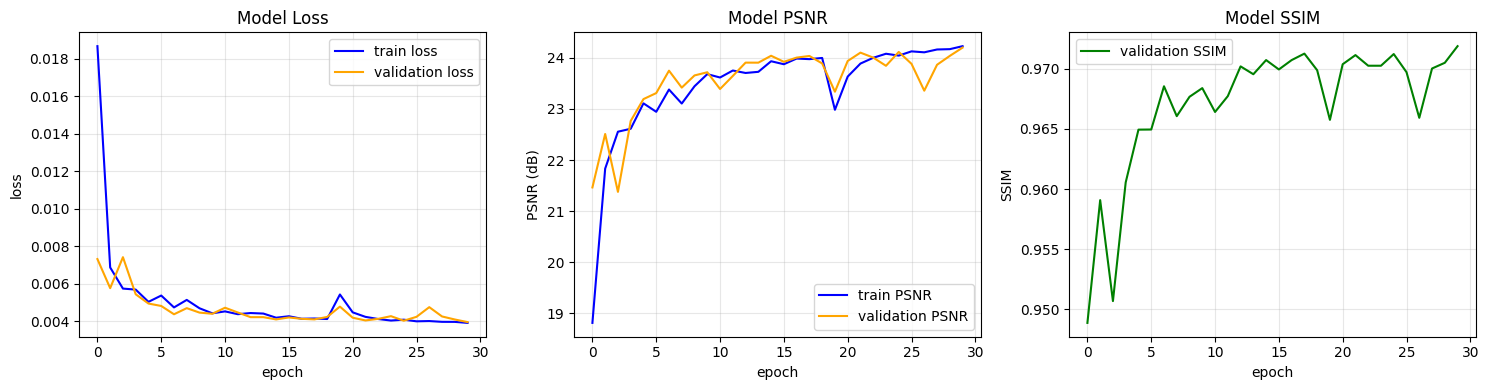

Epoch 30: Train Loss 0.0039 PSNR 24.23 | Val Loss 0.0040 PSNR 24.20 SSIM 0.9719
Training finished.


In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

class LivePlotter:
    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.train_psnr = []
        self.val_psnr = []
        self.val_ssim = []

    def update(self, train_loss, train_psnr, val_loss, val_psnr, val_ssim):
        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)
        self.train_psnr.append(train_psnr)
        self.val_psnr.append(val_psnr)
        self.val_ssim.append(val_ssim)

        clear_output(wait=True)
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))  # 3 plots

        # Loss plot
        ax1.plot(self.train_loss, label='train loss', color='blue')
        ax1.plot(self.val_loss, label='validation loss', color='orange')
        ax1.set_xlabel('epoch')
        ax1.set_ylabel('loss')
        ax1.set_title('Model Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # PSNR plot
        ax2.plot(self.train_psnr, label='train PSNR', color='blue')
        ax2.plot(self.val_psnr, label='validation PSNR', color='orange')
        ax2.set_xlabel('epoch')
        ax2.set_ylabel('PSNR (dB)')
        ax2.set_title('Model PSNR')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # SSIM plot (new!)
        ax3.plot(self.val_ssim, label='validation SSIM', color='green')
        ax3.set_xlabel('epoch')
        ax3.set_ylabel('SSIM')
        ax3.set_title('Model SSIM')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2)
    return 20 * torch.log10(1.0 / torch.sqrt(mse))

def calculate_ssim(img1, img2):
    """SSIM metric (0-1)"""
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu1 = torch.mean(img1)
    mu2 = torch.mean(img2)

    sigma1_sq = torch.var(img1)
    sigma2_sq = torch.var(img2)
    sigma12 = torch.mean((img1 - mu1) * (img2 - mu2))

    ssim = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / \
           ((mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2))

    return ssim

# Initialize
plotter = LivePlotter()
train_loss_hist, val_loss_hist = [], []
train_psnr_hist, val_psnr_hist, val_ssim_hist = [], [], []

print('Starting training...')

# Training Loop
for epoch in range(epochs):

    # TRAINING
    sr_model.train()
    running_loss, running_psnr, total = 0.0, 0.0, 0

    for lr_batch, hr_batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False):
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

        optimizer.zero_grad()
        sr_batch = sr_model(lr_batch)
        loss = criterion(sr_batch, hr_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * lr_batch.size(0)
        running_psnr += calculate_psnr(sr_batch, hr_batch).item() * lr_batch.size(0)
        total += lr_batch.size(0)

    train_loss = running_loss / total
    train_psnr = running_psnr / total

    # VALIDATION
    sr_model.eval()
    val_running_loss, val_running_psnr, val_running_ssim, val_total = 0.0, 0.0, 0.0, 0

    with torch.no_grad():
        for lr_batch, hr_batch in tqdm(val_dataloader, desc=f'Epoch {epoch+1}/{epochs} [Val]', leave=False):
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
            sr_batch = sr_model(lr_batch)
            loss = criterion(sr_batch, hr_batch)

            val_running_loss += loss.item() * lr_batch.size(0)
            val_running_psnr += calculate_psnr(sr_batch, hr_batch).item() * lr_batch.size(0)
            val_running_ssim += calculate_ssim(sr_batch, hr_batch).item() * lr_batch.size(0)
            val_total += lr_batch.size(0)

    val_loss = val_running_loss / val_total
    val_psnr = val_running_psnr / val_total
    val_ssim = val_running_ssim / val_total

    # Record history
    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_psnr_hist.append(train_psnr)
    val_psnr_hist.append(val_psnr)
    val_ssim_hist.append(val_ssim)

    # Update live plot
    plotter.update(train_loss, train_psnr, val_loss, val_psnr, val_ssim)
    print(f'Epoch {epoch+1}: Train Loss {train_loss:.4f} PSNR {train_psnr:.2f} | Val Loss {val_loss:.4f} PSNR {val_psnr:.2f} SSIM {val_ssim:.4f}')  # Updated!

print('Training finished.')

# IMPORTANT
Make sure your model definition in `models.py` has the class name
`SuperResolutionModel` and make sure you save your weights as `model.pth` e.g.
`torch.save(model, 'model.pth')`.

**DO NOT** submit a model which has more than 5 Million parameters. We will
reject in the backend.

In [ ]:
def count_model_parameters(model):
    return sum(p.numel() for p in model.parameters())

total_params = count_model_parameters(sr_model)
if total_params > 5000000:
    print("Model greater than 5 million params!! Reduce model complexity!!")
else:
    torch.save(sr_model.state_dict(), 'model.pth')